Graph Nodes, Heuristics, and Weighted Edges:
---------------------------------------------
Node: S (Heuristic: 7)
  --(1)--> A
  --(4)--> B

Node: A (Heuristic: 6)
  --(2)--> B
  --(5)--> C
  --(12)--> G

Node: B (Heuristic: 2)
  --(2)--> C

Node: C (Heuristic: 1)
  --(3)--> G

Node: G (Heuristic: 0)
  No outgoing edges.



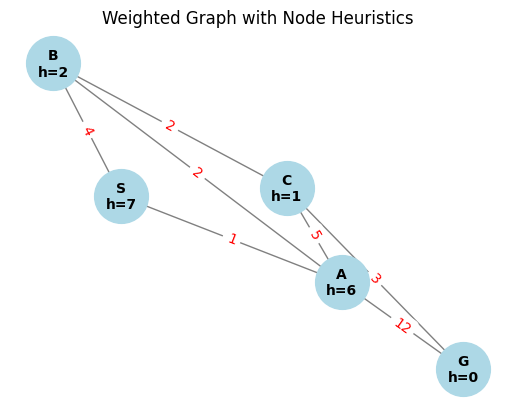

In [2]:
import networkx as nx
import matplotlib.pyplot as plt

# A simple graph representation with edge weights and node heuristics
# commonly used for algorithms like A* search.

# Heuristic values for each node (e.g., estimated straight-line distance to goal 'G')
heuristics = {
    'S': 7,
    'A': 6,
    'B': 2,
    'C': 1,
    'G': 0
}

# Graph represented as an adjacency list with edge weights
# Format: 'Node': [('Neighbor', Weight), ...]
graph = {
    'S': [('A', 1), ('B', 4)],
    'A': [('B', 2), ('C', 5), ('G', 12)],
    'B': [('C', 2)],
    'C': [('G', 3)],
    'G': []
}

def display_graph(graph, heuristics):
    print("Graph Nodes, Heuristics, and Weighted Edges:")
    print("-" * 45)
    for node in graph:
        h_val = heuristics.get(node, "N/A")
        print(f"Node: {node} (Heuristic: {h_val})")

        if not graph[node]:
            print("  No outgoing edges.")
        else:
            for neighbor, weight in graph[node]:
                print(f"  --({weight})--> {neighbor}")
        print()

def draw_graph(graph, heuristics):
    G = nx.DiGraph()

    # Add nodes
    for node in heuristics.keys():
        G.add_node(node)

    # Add edges with weights
    for node, edges in graph.items():
        for neighbor, weight in edges:
            G.add_edge(node, neighbor, weight=weight)

    # Use a layout for the nodes
    pos = nx.spring_layout(G, seed=42)

    # Draw nodes
    nx.draw_networkx_nodes(G, pos, node_size=1500, node_color='lightblue')

    # Draw node labels (Node Name + Heuristic)
    node_labels = {node: f"{node}\nh={heuristics.get(node, '?')}" for node in G.nodes()}
    nx.draw_networkx_labels(G, pos, labels=node_labels, font_size=10, font_weight="bold")

    # Draw edges
    nx.draw_networkx_edges(G, pos, arrowstyle="->", arrowsize=15, edge_color="gray")

    # Draw edge labels (Weights)
    edge_labels = nx.get_edge_attributes(G, 'weight')
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_color='red')

    plt.title("Weighted Graph with Node Heuristics")
    plt.axis('off')  # Turn off the axis
    plt.show()

if __name__ == "__main__":
    display_graph(graph, heuristics)
    draw_graph(graph, heuristics)


In [3]:
import heapq

def a_star(graph, heuristics, start, goal):
    # Priority queue stores (f_score, current_node, path, g_score)
    open_list = [(heuristics[start], start, [start], 0)]
    visited = {}

    while open_list:
        f, current, path, g = heapq.heappop(open_list)

        if current == goal:
            return path, g

        if current in visited and visited[current] <= g:
            continue
        visited[current] = g

        for neighbor, weight in graph.get(current, []):
            new_g = g + weight
            new_f = new_g + heuristics.get(neighbor, 0)
            heapq.heappush(open_list, (new_f, neighbor, path + [neighbor], new_g))

    return None, float('inf')

# Execution
path, cost = a_star(graph, heuristics, 'S', 'G')
print(f"Optimal Path: {' -> '.join(path)}")
print(f"Total Cost: {cost}")

Optimal Path: S -> A -> B -> C -> G
Total Cost: 8
